# Steam Player Engagement Analysis

I started by checking whether the three Steam tables were actually clean enough to trust. From there, the notebook moves into the question I care about more: **does high playtime actually line up with player satisfaction?**

I'm using recommendation behavior as the satisfaction signal and playtime as the engagement signal. The rest of the analysis looks at where those two measures agree, where they don't, and whether pricing changes the picture.

In [1]:

import pandas as pd
import numpy as np

games = pd.read_csv("../data/raw/games.csv")
users = pd.read_csv("../data/raw/users.csv")
recommendations = pd.read_csv("../data/raw/recommendations.csv")

## 1. Getting a feel for the data

First, I want to see what I'm working with: table sizes, columns, data types, and a few sample rows.

In [2]:
print("Games:", games.shape)
print("Users:", users.shape)
print("Recommendations:", recommendations.shape)

Games: (50872, 13)
Users: (14306064, 3)
Recommendations: (41154794, 8)


In [3]:
games.info()
users.info()
recommendations.info()

<class 'pandas.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          50872 non-null  int64  
 1   title           50872 non-null  str    
 2   date_release    50872 non-null  str    
 3   win             50872 non-null  bool   
 4   mac             50872 non-null  bool   
 5   linux           50872 non-null  bool   
 6   rating          50872 non-null  str    
 7   positive_ratio  50872 non-null  int64  
 8   user_reviews    50872 non-null  int64  
 9   price_final     50872 non-null  float64
 10  price_original  50872 non-null  float64
 11  discount        50872 non-null  float64
 12  steam_deck      50872 non-null  bool   
dtypes: bool(4), float64(3), int64(3), str(3)
memory usage: 3.7 MB
<class 'pandas.DataFrame'>
RangeIndex: 14306064 entries, 0 to 14306063
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   

In [4]:
display(games.head())
display(users.head())
display(recommendations.head())

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True


,user_id,products,reviews
0,7360263,359,0
1,14020781,156,1
2,8762579,329,4
3,4820647,176,4
4,5167327,98,2


,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0,0,2022-12-12,True,36.3,51580,0
1,304390,4,0,2017-02-17,False,11.5,2586,1
2,1085660,2,0,2019-11-17,True,336.5,253880,2
3,703080,0,0,2022-09-23,True,27.4,259432,3
4,526870,0,0,2021-01-10,True,7.9,23869,4


## 2. Basic data quality checks

Before doing anything more interesting, I'm checking for missing values across all three tables.

In [5]:
def basic_profile(df, name):
    print(f"\n--- {name} ---")
    print(f"Rows: {len(df):,}")
    print(f"Columns: {df.shape[1]}")
    
    print("\nMissing values:")
    print(df.isna().sum())
    
    print("\nMissing percentage:")
    print((df.isna().mean() * 100).round(2))


basic_profile(games, "Games")


--- Games ---
Rows: 50,872
Columns: 13

Missing values:
app_id            0
title             0
date_release      0
win               0
mac               0
linux             0
rating            0
positive_ratio    0
user_reviews      0
price_final       0
price_original    0
discount          0
steam_deck        0
dtype: int64

Missing percentage:
app_id            0.0
title             0.0
date_release      0.0
win               0.0
mac               0.0
linux             0.0
rating            0.0
positive_ratio    0.0
user_reviews      0.0
price_final       0.0
price_original    0.0
discount          0.0
steam_deck        0.0
dtype: float64


In [6]:
basic_profile(users, "Users")


--- Users ---
Rows: 14,306,064
Columns: 3

Missing values:
user_id     0
products    0
reviews     0
dtype: int64

Missing percentage:
user_id     0.0
products    0.0
reviews     0.0
dtype: float64


In [7]:
basic_profile(recommendations, "Recommendations")


--- Recommendations ---
Rows: 41,154,794
Columns: 8

Missing values:
app_id            0
helpful           0
funny             0
date              0
is_recommended    0
hours             0
user_id           0
review_id         0
dtype: int64

Missing percentage:
app_id            0.0
helpful           0.0
funny             0.0
date              0.0
is_recommended    0.0
hours             0.0
user_id           0.0
review_id         0.0
dtype: float64


### First pass

A few things stand out right away:

- No missing values show up in any of the three datasets.
- The recommendations table is by far the largest, with more than 41 million rows.
- The date fields came in as strings, so I'll convert those before doing anything time-based.

## 3. Are the IDs actually unique?

I'm expecting each table to have one clean identifier:

- `app_id` for games
- `user_id` for users
- `review_id` for recommendations

Worth checking before I treat any of them like primary keys.

In [8]:
print("Games")
print("Unique app_ids:", games["app_id"].nunique())
print("Total rows:", len(games))

print("\nUsers")
print("Unique user_ids:", users["user_id"].nunique())
print("Total rows:", len(users))

print("\nRecommendations")
print("Unique review_ids:", recommendations["review_id"].nunique())
print("Total rows:", len(recommendations))

Games
Unique app_ids: 50872
Total rows: 50872

Users
Unique user_ids: 14306064
Total rows: 14306064

Recommendations
Unique review_ids: 41154794
Total rows: 41154794


### IDs look clean

All three expected IDs are unique in their respective tables, so I'm comfortable treating them as primary keys going forward.

## 4. Do the tables actually connect cleanly?

The recommendations table links users to games through `user_id` and `app_id`. Before joining anything, I want to make sure those IDs actually exist in the user and game tables.

In [9]:
valid_user_ids = recommendations["user_id"].isin(users["user_id"])
valid_app_ids = recommendations["app_id"].isin(games["app_id"])

print("Recommendation rows with valid user_id:")
print(f"{valid_user_ids.mean():.2%}")

print("\nRecommendation rows with valid app_id:")
print(f"{valid_app_ids.mean():.2%}")

print("\nRecommendations with unmatched user_id:")
print(f"{(~valid_user_ids).sum():,}")

print("\nRecommendations with unmatched app_id:")
print(f"{(~valid_app_ids).sum():,}")

Recommendation rows with valid user_id:
100.00%

Recommendation rows with valid app_id:
100.00%

Recommendations with unmatched user_id:
0

Recommendations with unmatched app_id:
0


### No orphaned records

Every recommendation maps to a valid user and a valid game. That means I can join the tables on `user_id` and `app_id` without quietly dropping unmatched recommendation records.

## 5. Checking the values themselves

The IDs are clean, but that doesn't mean every field is. I'm checking the main numerical and categorical columns for strange ranges, extreme values, and anything that could distort the analysis later.

In [10]:
# checking ranges before I trust these fields in comparisons

games.describe()

,app_id,positive_ratio,user_reviews,price_final,price_original,discount
count,5.087200e+04,50872.000000,5.087200e+04,50872.000000,50872.000000,50872.000000
mean,1.055224e+06,77.052033,1.824425e+03,8.620325,8.726788,5.592212
std,6.103249e+05,18.253592,4.007352e+04,11.514164,11.507021,18.606679
min,1.000000e+01,0.000000,1.000000e+01,0.000000,0.000000,0.000000
25%,5.287375e+05,67.000000,1.900000e+01,0.990000,0.990000,0.000000
50%,9.860850e+05,81.000000,4.900000e+01,4.990000,4.990000,0.000000
75%,1.524895e+06,91.000000,2.060000e+02,10.990000,11.990000,0.000000
max,2.599300e+06,100.000000,7.494460e+06,299.990000,299.990000,90.000000


In [11]:
# mostly checking for weird category values

print("Release date range:")
print(games["date_release"].min(), "to", games["date_release"].max())

print("\nRatings:")
print(games["rating"].value_counts())

print("\nPrice range:")
print(games["price_final"].min(), "to", games["price_final"].max())

print("\nDiscount range:")
print(games["discount"].min(), "to", games["discount"].max())

print("\nPositive ratio range:")
print(games["positive_ratio"].min(), "to", games["positive_ratio"].max())

Release date range:
1997-06-30 to 2023-10-24

Ratings:
rating
Positive                   13502
Very Positive              13139
Mixed                      12157
Mostly Positive             8738
Mostly Negative             1849
Overwhelmingly Positive     1110
Negative                     303
Very Negative                 60
Overwhelmingly Negative       14
Name: count, dtype: int64

Price range:
0.0 to 299.99

Discount range:
0.0 to 90.0

Positive ratio range:
0 to 100


### What stands out in the game data

- Release dates run from 1997 through 2023.
- `positive_ratio` stays within 0–100, which is what I'd expect.
- Final prices range from free to $299.99.
- Discounts run from 0% to 90%, with most games not discounted.
- Review volume is extremely uneven: some games have 10 reviews while others have millions. I'll need a minimum-review cutoff before comparing individual titles.
- Steam ratings span the full range from Overwhelmingly Negative to Overwhelmingly Positive.

In [12]:
# expecting a long tail here
users.describe()

,user_id,products,reviews
count,1.430606e+07,1.430606e+07,1.430606e+07
mean,7.153032e+06,1.163734e+02,2.876738e+00
std,4.129805e+06,2.438515e+02,7.987421e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.576516e+06,2.300000e+01,1.000000e+00
50%,7.153032e+06,5.500000e+01,1.000000e+00
75%,1.072955e+07,1.270000e+02,3.000000e+00
max,1.430606e+07,3.221400e+04,6.045000e+03


In [13]:
# checking the tails before deciding whether any values need special handling
print("Products owned:")
print("Min:", users["products"].min())
print("Median:", users["products"].median())
print("Mean:", round(users["products"].mean(), 2))
print("Max:", users["products"].max())

print("\nReviews written:")
print("Min:", users["reviews"].min())
print("Median:", users["reviews"].median())
print("Mean:", round(users["reviews"].mean(), 2))
print("Max:", users["reviews"].max())

print("\nUsers with zero products:")
print(f"{(users['products'] == 0).sum():,}")

print("\nUsers with zero reviews:")
print(f"{(users['reviews'] == 0).sum():,}")

Products owned:
Min: 0
Median: 55.0
Mean: 116.37
Max: 32214

Reviews written:
Min: 0
Median: 1.0
Mean: 2.88
Max: 6045

Users with zero products:
139,318

Users with zero reviews:
525,005


### User activity is very skewed

The typical user looks pretty different from the average user here. Median library size is 55 products, while the mean is around 116, and the same kind of long tail shows up in review counts.

There are also a few users with zero products or zero reviews and some extremely active accounts. I'm not dropping those automatically; for this dataset, medians and percentiles will usually be more informative than averages.

## 6. Looking more closely at recommendation activity

This is the table that contains the behavior I actually care about: playtime and whether someone recommends the game. I'm checking those fields before I start treating playtime as engagement.

In [14]:
# playtime is the field I'm most suspicious of here
recommendations.describe()

,app_id,helpful,funny,hours,user_id,review_id
count,4.115479e+07,4.115479e+07,4.115479e+07,4.115479e+07,4.115479e+07,4.115479e+07
mean,6.032724e+05,3.202567e+00,1.058071e+00,1.006022e+02,7.450576e+06,2.057740e+07
std,4.729233e+05,4.693649e+01,2.867060e+01,1.761675e+02,4.010685e+06,1.188037e+07
min,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.539400e+05,0.000000e+00,0.000000e+00,7.800000e+00,4.287256e+06,1.028870e+07
50%,4.351500e+05,0.000000e+00,0.000000e+00,2.730000e+01,7.546446e+06,2.057740e+07
75%,9.331100e+05,0.000000e+00,0.000000e+00,9.920000e+01,1.096877e+07,3.086609e+07
max,2.253290e+06,3.621200e+04,2.810900e+04,1.000000e+03,1.430606e+07,4.115479e+07


### One boundary caught my attention

Playtime is heavily skewed, which isn't surprising, but the exact maximum of 1,000 hours made me wonder whether the field might be capped. I'm checking the upper tail before deciding how much that matters.

In [15]:
# the exact 1,000-hour max looks suspicious enough to check
print("Reviews with exactly 0 hours:")
print(f"{(recommendations['hours'] == 0).sum():,}")

print("\nReviews with exactly 1,000 hours:")
print(f"{(recommendations['hours'] == 1000).sum():,}")

print("\nPercentage at 1,000 hours:")
print(f"{(recommendations['hours'] == 1000).mean():.4%}")

print("\nHighest playtime values:")
print(recommendations["hours"].nlargest(20).to_list())

Reviews with exactly 0 hours:
176,329

Reviews with exactly 1,000 hours:
26

Percentage at 1,000 hours:
0.0001%

Highest playtime values:
[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0]


In [16]:
# percentiles tell me whether that upper boundary affects more than a tiny tail
print(
    recommendations["hours"].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
    )
)

0.500     27.3
0.750     99.2
0.900    304.0
0.950    517.4
0.990    864.5
0.999    985.2
Name: hours, dtype: float64


### The 1,000-hour ceiling isn't a big problem

Median playtime is 27.3 hours, compared with a mean of 100.6, so the distribution has a very long right tail. About 10% of reviews are above 304 hours and 1% are above 864.5 hours.

There are only 26 records at exactly 1,000 hours, though, so even if that value is a cap, it affects a tiny fraction of the data. I'll keep the records and lean on medians and percentiles when describing engagement.

In [17]:
print("Recommendation counts:")
print(recommendations["is_recommended"].value_counts())

print("\nRecommendation percentages:")
print(
    recommendations["is_recommended"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nReview date range:")
print(
    recommendations["date"].min(),
    "to",
    recommendations["date"].max()
)

Recommendation counts:
is_recommended
True     35304398
False     5850396
Name: count, dtype: int64

Recommendation percentages:
is_recommended
True     85.78
False    14.22
Name: proportion, dtype: float64

Review date range:
2010-10-15 to 2022-12-31


### Recommendations are mostly positive

About 85.8% of reviews recommend the game. Reviews span October 2010 through December 2022.

That high baseline matters later: a game can have what looks like a strong recommendation rate in isolation and still be below average for this dataset.

In [18]:
# zero hours could be real behavior, so I'm checking it instead of dropping it
zero_hours = recommendations[recommendations["hours"] == 0]

print("Zero-hour reviews:", f"{len(zero_hours):,}")

print("\nRecommendation distribution:")
print(
    zero_hours["is_recommended"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nSample zero-hour reviews:")
display(zero_hours.head(10))

Zero-hour reviews: 176,329

Recommendation distribution:
is_recommended
True     59.95
False    40.05
Name: proportion, dtype: float64

Sample zero-hour reviews:


,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
7820,294100,2,0,2017-12-08,True,0.0,2599746,7820
86894,202970,2,0,2012-11-15,True,0.0,12698158,86894
117513,244850,0,0,2015-10-10,False,0.0,5999826,117513
118242,1151340,0,0,2021-07-03,False,0.0,3037616,118242
168724,252490,0,0,2021-08-23,True,0.0,2769196,168724
237312,381210,2,0,2022-06-26,True,0.0,3189265,237312
252353,381210,0,0,2022-04-10,True,0.0,11411643,252353
255648,271590,0,0,2019-10-15,True,0.0,4892238,255648
288252,291550,0,0,2022-01-24,False,0.0,8343880,288252
325709,252490,0,0,2021-10-17,True,0.0,10666565,325709


In [19]:
# checking the apparent recording precision around zero
print(
    recommendations.loc[
        recommendations["hours"] > 0, "hours"
    ].nsmallest(20).to_list()
)

[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]


### I'm keeping the zero-playtime reviews

There are 176,329 reviews with 0 recorded hours. They're unusual, but they don't look like simple missing values: their recommendation rate is about 60%, well below the overall 85.8% rate.

Rather than deleting them, I'm keeping them as observed behavior. For engagement-specific comparisons, I can separate them from players with recorded playtime if needed.

## 7. Cleaning only what I need

I'm keeping the transformations pretty light: convert the date fields and create a few features that make the product comparisons easier later.

In [20]:
games["date_release"] = pd.to_datetime(games["date_release"])
recommendations["date"] = pd.to_datetime(recommendations["date"])

print("Games release date type:", games["date_release"].dtype)
print("Recommendation date type:", recommendations["date"].dtype)

Games release date type: datetime64[us]
Recommendation date type: datetime64[us]


In [21]:
games["release_year"] = games["date_release"].dt.year

recommendations["review_year"] = recommendations["date"].dt.year
recommendations["review_month"] = recommendations["date"].dt.month

In [22]:
display(
    games[
        ["date_release", "release_year"]
    ].head()
)

display(
    recommendations[
        ["date", "review_year", "review_month"]
    ].head()
)

,date_release,release_year
0,2008-11-21,2008
1,2011-08-03,2011
2,2013-04-24,2013
3,2014-11-18,2014
4,2014-10-27,2014


,date,review_year,review_month
0,2022-12-12,2022,12
1,2017-02-17,2017,2
2,2019-11-17,2019,11
3,2022-09-23,2022,9
4,2021-01-10,2021,1


### One pricing field needs a closer look

I want to make sure `price_original`, `price_final`, and `discount` agree with each other before I use them.

In [23]:
# making sure the price fields agree before using them
print("Final price greater than original price:")
print(f"{(games['price_final'] > games['price_original']).sum():,}")

print("\nDiscounted games:")
print(f"{(games['discount'] > 0).sum():,}")

print("\nFree games:")
print(f"{(games['price_final'] == 0).sum():,}")

print("\nGames with zero original price:")
print(f"{(games['price_original'] == 0).sum():,}")

Final price greater than original price:
985

Discounted games:
4,969

Free games:
9,105

Games with zero original price:
10,090


In [24]:
# does the listed discount actually match the prices?
paid_games = games[games["price_original"] > 0].copy()

paid_games["calculated_discount"] = (
    (1 - paid_games["price_final"] / paid_games["price_original"]) * 100
)

paid_games["discount_difference"] = (
    paid_games["calculated_discount"] - paid_games["discount"]
).abs()

print("Median difference:")
print(round(paid_games["discount_difference"].median(), 2))

print("\nMaximum difference:")
print(round(paid_games["discount_difference"].max(), 2))

print("\nGames with >1 percentage point difference:")
print(f"{(paid_games['discount_difference'] > 1).sum():,}")

Median difference:
0.0

Maximum difference:
1.0

Games with >1 percentage point difference:
0


### Most of the pricing data checks out

The discount field is internally consistent: there are no differences larger than one percentage point between the listed discount and the discount implied by valid original/final prices.

The odd part is the 985 games where `price_final` is higher than `price_original`. I'm checking those separately rather than assuming they're bad rows.

In [25]:
# these are odd enough to inspect rather than automatically remove
price_anomalies = games[
    games["price_final"] > games["price_original"]
]

display(
    price_anomalies[
        [
            "app_id",
            "title",
            "price_final",
            "price_original",
            "discount",
            "date_release"
        ]
    ].head(20)
)

,app_id,title,price_final,price_original,discount,date_release
33,371970,Barony,20.00,0.0,0.0,2015-06-23
74,314000,Pool Nation FX Lite,9.99,0.0,0.0,2015-12-07
287,919640,Steel Division 2,40.00,0.0,0.0,2019-06-20
480,552520,Far Cry® 5,60.00,0.0,0.0,2018-03-26
619,1436950,Sid Meier's Civilization® VI: Vietnam & Kublai...,9.00,0.0,0.0,2021-01-28
739,797280,The Surge - Cutting Edge Pack,24.99,0.0,0.0,2018-04-17
799,1378990,Crash Bandicoot™ 4: It's About Time,20.00,0.0,0.0,2022-10-18
975,1454970,New Tales from the Borderlands,25.00,0.0,0.0,2022-10-20
1154,1943950,Escape the Backrooms,10.00,0.0,0.0,2022-08-11
1174,1235731,The Sims™ 4 City Living,40.00,0.0,0.0,2020-06-18


In [26]:
# checking whether the anomaly follows one consistent pattern
print(
    price_anomalies[
        ["price_final", "price_original", "discount"]
    ].describe()
)

print("\nOriginal price = 0:")
print(f"{(price_anomalies['price_original'] == 0).sum():,}")

print("\nDiscount = 0:")
print(f"{(price_anomalies['discount'] == 0).sum():,}")

       price_final  price_original  discount
count   985.000000           985.0     985.0
mean     25.826802             0.0       0.0
std      16.878519             0.0       0.0
min       0.990000             0.0       0.0
25%      14.990000             0.0       0.0
50%      20.000000             0.0       0.0
75%      35.000000             0.0       0.0
max     150.000000             0.0       0.0

Original price = 0:
985

Discount = 0:
985


### The "price anomaly" is mostly an original-price issue

Those 985 records are mainly games with `price_original = 0` but a non-zero final price. That makes the original-price field look incomplete for those titles rather than the final price being obviously wrong.

So for the rest of the notebook:

- `price_final` is my main current-price field.
- `price_final == 0` defines a free game.
- I won't use `price_original == 0` as evidence that a game is free.
- I'll use the supplied `discount` field for discount analysis because it behaves consistently when the original price is valid.

## 8. A few features for the analysis

Now that the main fields look usable, I'm creating the pricing, promotion, and time features I'll need later.

In [27]:
games["price_type"] = np.where(
    games["price_final"] == 0,
    "Free",
    "Paid"
)

games["is_discounted"] = games["discount"] > 0

In [28]:
print("Price type:")
print(games["price_type"].value_counts())

print("\nDiscount status:")
print(games["is_discounted"].value_counts())

Price type:
price_type
Paid    41767
Free     9105
Name: count, dtype: int64

Discount status:
is_discounted
False    45903
True      4969
Name: count, dtype: int64


In [29]:
display(
    games[
        [
            "title",
            "price_final",
            "price_original",
            "discount",
            "price_type",
            "is_discounted"
        ]
    ].sample(10, random_state=42)
)

,title,price_final,price_original,discount,price_type,is_discounted
39742,Super Blackjack Battle 2 Turbo Edition - The C...,11.99,11.99,0.0,Paid,False
27284,Galactic Dominion,4.99,4.99,0.0,Paid,False
27443,Watching Delusion,0.99,0.99,0.0,Paid,False
23467,Long Road,0.59,0.99,40.0,Paid,True
45513,The Mutational,0.00,0.00,0.0,Free,False
24969,Flying Neko Delivery,16.99,19.99,15.0,Paid,True
31637,Breach & Clear: Deadline Rebirth (2016),9.99,9.99,0.0,Paid,False
45568,Forza Horizon 5 2014 SafariZ 370Z,2.99,2.99,0.0,Paid,False
46045,Heroes Of Avranche,0.00,0.00,0.0,Free,False
2191,Formata,9.99,9.99,0.0,Paid,False


### How should I define "engaged"?

Playtime varies wildly, so I don't want to invent cutoffs like "10 hours = engaged" without looking at the distribution first. I'm using the observed percentiles to create engagement bands that are interpretable but still reflect this dataset.

In [30]:
# using the data's own quartiles instead of arbitrary cutoffs
percentiles = [0, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

playtime_percentiles = (
    recommendations["hours"]
    .quantile(percentiles)
    .round(1)
)

print(playtime_percentiles)

0.00      0.0
0.10      2.1
0.25      7.8
0.50     27.3
0.75     99.2
0.90    304.0
0.95    517.4
0.99    864.5
Name: hours, dtype: float64


In [31]:
# first hint that playtime and satisfaction may not move together
recommendation_playtime = (
    recommendations
    .groupby("is_recommended")["hours"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(recommendation_playtime)

,count,mean,median
is_recommended,,,
False,5850396,80.89,11.1
True,35304398,103.87,30.3


### Engagement bands

I'm using percentile-informed cutoffs:

| Segment | Playtime |
|---|---:|
| Minimal | < 2.1 hours |
| Casual | 2.1–7.7 hours |
| Moderate | 7.8–27.2 hours |
| Engaged | 27.3–99.1 hours |
| Highly Engaged | 99.2–303.9 hours |
| Power Player | 304+ hours |

These describe engagement with the **specific game being reviewed**, not how engaged that person is with Steam overall.

In [32]:
bins = [-np.inf, 2.1, 7.8, 27.3, 99.2, 304, np.inf]

labels = [
    "Minimal",
    "Casual",
    "Moderate",
    "Engaged",
    "Highly Engaged",
    "Power Player"
]

recommendations["engagement_segment"] = pd.cut(
    recommendations["hours"],
    bins=bins,
    labels=labels,
    right=False
)

In [33]:
segment_counts = (
    recommendations["engagement_segment"]
    .value_counts(sort=False)
)

segment_pct = (
    recommendations["engagement_segment"]
    .value_counts(normalize=True, sort=False)
    .mul(100)
    .round(2)
)

engagement_distribution = pd.DataFrame({
    "reviews": segment_counts,
    "percentage": segment_pct
})

display(engagement_distribution)

,reviews,percentage
engagement_segment,,
Minimal,4094318,9.95
Casual,6157033,14.96
Moderate,10312486,25.06
Engaged,10299234,25.03
Highly Engaged,6174420,15.00
Power Player,4117303,10.00


## 9. Does more playtime mean happier players?

This is the main question that motivated the project. I'm comparing recommendation rates across the playtime bands, using recommendation as a rough satisfaction signal.

In [34]:
engagement_analysis = (
    recommendations
    .groupby("engagement_segment", observed=True)
    .agg(
        reviews=("review_id", "count"),
        avg_hours=("hours", "mean"),
        median_hours=("hours", "median"),
        recommendation_rate=("is_recommended", "mean")
    )
)

engagement_analysis["recommendation_rate"] *= 100

engagement_analysis = engagement_analysis.round({
    "avg_hours": 1,
    "median_hours": 1,
    "recommendation_rate": 2
})

display(engagement_analysis)

,reviews,avg_hours,median_hours,recommendation_rate
engagement_segment,,,,
Minimal,4094318,0.9,0.9,63.31
Casual,6157033,4.8,4.7,82.39
Moderate,10312486,15.8,15.0,88.81
Engaged,10299234,54.2,50.0,90.36
Highly Engaged,6174420,174.9,162.4,90.02
Power Player,4117303,560.1,517.3,87.83


### Mostly yes — until the very top

Recommendation rate climbs from 63.31% in the Minimal group to 90.36% in the Engaged group.

But it doesn't keep climbing. Highly Engaged players are basically flat at 90.02%, and Power Players fall to 87.83% despite having dramatically more playtime.

So engagement and satisfaction are clearly related here, but they aren't interchangeable. Someone spending hundreds of hours in a game doesn't automatically mean they're the happiest player.

### Seeing the pattern

The bar chart makes the plateau at the high end easier to see.

Matplotlib is building the font cache; this may take a moment.


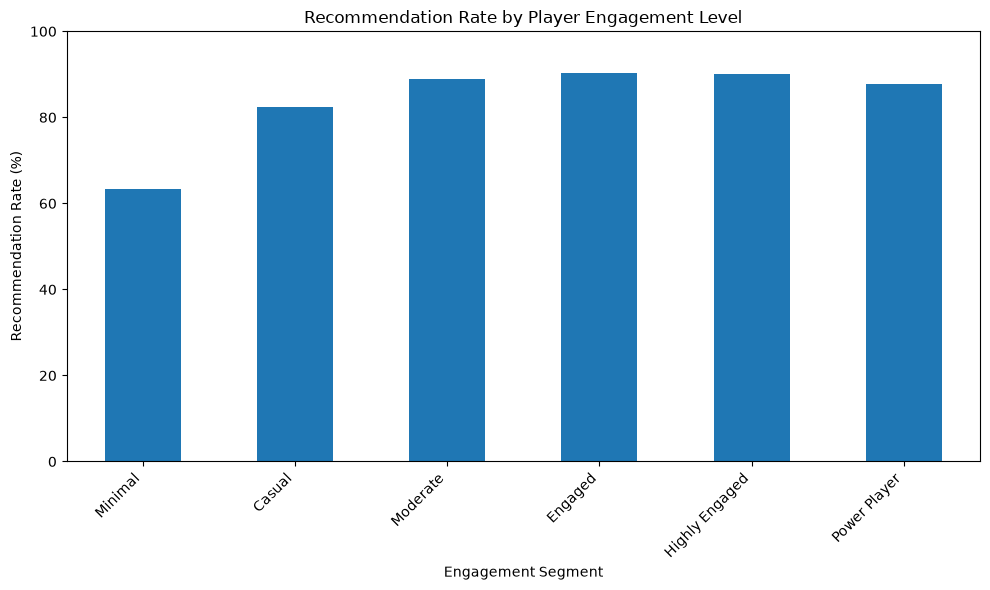

In [37]:
import matplotlib.pyplot as plt

ax = engagement_analysis["recommendation_rate"].plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Recommendation Rate by Player Engagement Level")
ax.set_xlabel("Engagement Segment")
ax.set_ylabel("Recommendation Rate (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### This is the pattern I was looking for

The biggest gains in recommendation rate happen as players move out of the lowest-engagement groups. By the time we reach the Engaged segment, the relationship mostly flattens, then dips for Power Players.

That's important for the rest of the project: **playtime is useful, but I don't want to treat it as a satisfaction metric by itself.**

And because this is observational data, I'm describing an association here — not claiming that playing longer causes someone to like a game more.

## 10. Moving from players to games

The player-level pattern is useful, but product teams make decisions about games. I'm aggregating the recommendation data to one row per game so I can compare engagement and satisfaction alongside the game attributes.

### Building one row per game

For each title, I'm keeping review volume, unique reviewers, recommendation rate, and both average and median playtime. Aggregating first also makes the later joins much more manageable than carrying 41 million recommendation rows around.

In [38]:
game_metrics = (
    recommendations
    .groupby("app_id")
    .agg(
        total_reviews=("review_id", "count"),
        unique_reviewers=("user_id", "nunique"),
        recommendation_rate=("is_recommended", "mean"),
        avg_hours=("hours", "mean"),
        median_hours=("hours", "median")
    )
    .reset_index()
)

game_metrics["recommendation_rate"] *= 100

In [39]:
print("Game-level records:", f"{len(game_metrics):,}")

display(game_metrics.head())

display(
    game_metrics[
        [
            "total_reviews",
            "unique_reviewers",
            "recommendation_rate",
            "avg_hours",
            "median_hours"
        ]
    ].describe()
)

Game-level records: 37,610


,app_id,total_reviews,unique_reviewers,recommendation_rate,avg_hours,median_hours
0,10,41043,41043,95.831201,245.776802,111.4
1,20,4284,4284,86.017740,35.180766,2.7
2,30,4432,4432,89.733755,78.345194,8.4
3,40,1610,1610,80.745342,29.885466,1.1
4,50,9721,9721,95.494291,18.470209,7.5


,total_reviews,unique_reviewers,recommendation_rate,avg_hours,median_hours
count,37610.000000,37610.000000,37610.000000,37610.000000,37610.000000
mean,1094.251369,1094.250811,76.744067,16.255161,7.616133
std,7689.340463,7689.336084,19.433195,31.495529,18.348563
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,13.000000,13.000000,66.666667,2.537551,1.000000
50%,39.000000,39.000000,81.176471,6.236682,3.000000
75%,179.750000,179.750000,91.538857,15.116959,6.900000
max,319492.000000,319491.000000,100.000000,487.000000,511.500000


In [40]:
# making sure repeated user-game reviews won't distort the aggregation
duplicate_user_game_reviews = (
    recommendations
    .duplicated(subset=["user_id", "app_id"])
    .sum()
)

print(
    "Duplicate user-game review records:",
    f"{duplicate_user_game_reviews:,}"
)

Duplicate user-game review records: 21


### The aggregation looks reliable

There are 37,610 games represented in the recommendation data. Review volume is extremely uneven — the median game has only 39 reviews, while the largest titles have hundreds of thousands.

I also found only 21 repeated user-game combinations across more than 41 million rows, which is negligible enough that I'm leaving them in.

The bigger issue is small samples, so I'll deal with that before ranking or comparing individual games.

### Adding the product attributes

Now I'm joining those game-level behavior metrics back to the Steam product table so I can compare them with price, discounts, release year, platform support, and Steam rating.

In [41]:
game_analysis = games.merge(
    game_metrics,
    on="app_id",
    how="left"
)

print("Games in product dataset:", f"{len(games):,}")
print("Games in analysis dataset:", f"{len(game_analysis):,}")

display(game_analysis.head())

Games in product dataset: 50,872
Games in analysis dataset: 50,872


,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,...,discount,steam_deck,release_year,price_type,is_discounted,total_reviews,unique_reviewers,recommendation_rate,avg_hours,median_hours
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,...,0.0,True,2008,Paid,False,1686.0,1686.0,84.578885,18.967912,12.9
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,...,0.0,True,2011,Paid,False,NaN,NaN,NaN,NaN,NaN
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,...,0.0,True,2013,Paid,False,6943.0,6943.0,90.854098,20.413294,6.9
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,...,0.0,True,2014,Paid,False,877.0,877.0,62.599772,10.776625,8.1
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,...,0.0,True,2014,Paid,False,4850.0,4850.0,88.556701,40.621691,23.4


In [42]:
# some catalog games may never show up in the review data
games_with_reviews = game_analysis["total_reviews"].notna().sum()
games_without_reviews = game_analysis["total_reviews"].isna().sum()

print("Games with recommendation data:", f"{games_with_reviews:,}")
print("Games without recommendation data:", f"{games_without_reviews:,}")

print(
    "Coverage:",
    f"{games_with_reviews / len(game_analysis):.2%}"
)

Games with recommendation data: 37,610
Games without recommendation data: 13,262
Coverage: 73.93%


In [43]:
# and did every reviewed game match back to the catalog?
unmatched_metrics = game_metrics[
    ~game_metrics["app_id"].isin(games["app_id"])
]

print(
    "Recommendation games without product information:",
    f"{len(unmatched_metrics):,}"
)

Recommendation games without product information: 0


### Join coverage

37,610 of the 50,872 games in the product table have recommendation/playtime data, or 73.93%. All games from the recommendation table matched successfully.

I'm keeping the other 13,262 games in the combined table, but they won't be part of analyses that require behavioral metrics.

## 11. Product-level comparisons

Before comparing individual titles, I need to deal with the fact that a 100% recommendation rate based on 10 reviews is not the same thing as 100% based on 10,000.

In [44]:
# enough reviews to trust the rate, without gutting the catalog
review_thresholds = [10, 25, 50, 100, 500, 1000]

threshold_summary = []

for threshold in review_thresholds:
    qualifying_games = (game_analysis["total_reviews"] >= threshold).sum()
    
    threshold_summary.append({
        "minimum_reviews": threshold,
        "qualifying_games": qualifying_games,
        "pct_of_reviewed_games": (
            qualifying_games / games_with_reviews * 100
        )
    })

threshold_summary = pd.DataFrame(threshold_summary)

threshold_summary["pct_of_reviewed_games"] = (
    threshold_summary["pct_of_reviewed_games"].round(2)
)

display(threshold_summary)

,minimum_reviews,qualifying_games,pct_of_reviewed_games
0,10,31226,83.03
1,25,22649,60.22
2,50,16977,45.14
3,100,12460,33.13
4,500,5450,14.49
5,1000,3685,9.80


### I'm using 100 reviews as the cutoff

At 100 reviews, I still have 12,460 games — about a third of the reviewed catalog — while avoiding the noisiest tiny samples.

Going down to 10 or 25 reviews keeps much more of the catalog but makes rankings pretty unstable. Going up to 500 or 1,000 throws away most titles. So 100 feels like a reasonable compromise for this project, not a magic statistical threshold.

In [45]:
reliable_games = game_analysis[
    game_analysis["total_reviews"] >= 100
].copy()

print("Games in reliable sample:", f"{len(reliable_games):,}")

Games in reliable sample: 12,460


Now I can get into the product questions: do games with stronger recommendation rates also keep players around longer? Does price relate more to engagement or satisfaction? And are highly reviewed games necessarily better-liked?

In [ ]:
# Spearman fits these heavily skewed variables better than Pearson
correlation_cols = [
    "recommendation_rate",
    "median_hours",
    "avg_hours",
    "positive_ratio",
    "price_final",
    "discount",
    "total_reviews"
]

correlation_matrix = (
    reliable_games[correlation_cols]
    .corr(method="spearman")
    .round(3)
)

display(correlation_matrix)

,recommendation_rate,median_hours,avg_hours,positive_ratio,price_final,discount,total_reviews
recommendation_rate,1.000,0.189,0.078,0.960,0.082,-0.022,0.225
median_hours,0.189,1.000,0.878,0.163,0.533,-0.018,0.422
avg_hours,0.078,0.878,1.000,0.061,0.386,-0.041,0.391
positive_ratio,0.960,0.163,0.061,1.000,0.070,-0.028,0.234
price_final,0.082,0.533,0.386,0.070,1.000,-0.151,0.198
discount,-0.022,-0.018,-0.041,-0.028,-0.151,1.000,-0.025
total_reviews,0.225,0.422,0.391,0.234,0.198,-0.025,1.000


### The correlations already separate engagement from satisfaction

A few things stand out:

- Recommendation rate and Steam's `positive_ratio` are almost the same signal (ρ = 0.960), which makes sense.
- Median playtime has a moderate positive relationship with price (ρ = 0.533) and review volume (ρ = 0.422).
- Recommendation rate and median playtime are only weakly related at the game level (ρ = 0.189).
- Current discount percentage barely relates to recommendation rate, playtime, or review volume here.

I'm using **Spearman**, not Pearson, because playtime, review volume, and price are heavily skewed. I care more about the rank-order relationship than letting a few giant values drive the coefficient.

Again, these are associations, not causal effects.

### Free vs. paid

Do free games look meaningfully different from paid games in satisfaction, engagement, or popularity?

In [47]:
price_type_analysis = (
    reliable_games
    .groupby("price_type")
    .agg(
        games=("app_id", "count"),
        median_recommendation_rate=("recommendation_rate", "median"),
        median_playtime=("median_hours", "median"),
        median_reviews=("total_reviews", "median")
    )
    .round(2)
)

display(price_type_analysis)

,games,median_recommendation_rate,median_playtime,median_reviews
price_type,,,,
Free,2063,82.88,2.7,426.0
Paid,10397,84.44,7.0,386.0


### Paid games have much deeper typical playtime

Paid games have a slightly higher median recommendation rate: 84.44% versus 82.88% for free games. That's not a huge gap.

Playtime is a different story. Median playtime is 7.0 hours for paid games and 2.7 hours for free games. Free games actually have slightly more reviews at the median (426 vs. 386).

So the pricing-model difference shows up much more strongly in **engagement** than in satisfaction. That doesn't mean charging for a game causes people to play longer — game type, audience, and lots of other differences are mixed in here.

But is that 7.0 vs. 2.7 hour gap just a few extreme games pulling things around?

In [48]:
# making sure this isn't just a mean/outlier story
price_playtime_distribution = (
    reliable_games
    .groupby("price_type")["median_hours"]
    .quantile([0.25, 0.50, 0.75, 0.90])
    .unstack()
    .round(2)
)

price_playtime_distribution.columns = [
    "25th_percentile",
    "median",
    "75th_percentile",
    "90th_percentile"
]

display(price_playtime_distribution)

,25th_percentile,median,75th_percentile,90th_percentile
price_type,,,,
Free,1.0,2.7,10.0,30.48
Paid,3.5,7.0,15.1,31.67


### It's not just the extreme tail

Paid games have higher typical playtime at the 25th, 50th, and 75th percentiles. By the 90th percentile, though, the gap almost disappears: 31.67 hours for paid games versus 30.48 for free games.

So the free/paid difference is mostly happening among lower- and moderately-engaging titles. The highly engaging games can reach similar playtime either way.

### What about price within paid games?

If I ignore free games and just look at paid titles, does a higher price line up with deeper engagement or better recommendations?

In [49]:
# let the price distribution tell me where the groups should fall
paid_reliable_games = reliable_games[
    reliable_games["price_type"] == "Paid"
].copy()

print(
    paid_reliable_games["price_final"]
    .quantile([0, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1])
    .round(2)
)

0.00      0.27
0.10      1.99
0.25      4.99
0.50      9.99
0.75     19.99
0.90     29.99
0.95     39.99
0.99     59.99
1.00    149.00
Name: price_final, dtype: float64


The paid-game price distribution is pretty wide, so I'm looking at relative price tiers rather than choosing arbitrary dollar cutoffs.

#### Splitting paid games into price quartiles

Quartiles give me similarly sized groups and let me compare low- versus high-priced games relative to the catalog I actually have.

In [50]:
paid_reliable_games["price_tier"] = pd.qcut(
    paid_reliable_games["price_final"],
    q=4,
    labels=[
        "Low Price",
        "Lower-Mid Price",
        "Upper-Mid Price",
        "High Price"
    ]
)

print(
    paid_reliable_games["price_tier"]
    .value_counts(sort=False)
)

price_tier
Low Price          2993
Lower-Mid Price    2428
Upper-Mid Price    3276
High Price         1700
Name: count, dtype: int64


In [51]:
price_tier_analysis = (
    paid_reliable_games
    .groupby("price_tier", observed=True)
    .agg(
        games=("app_id", "count"),
        median_price=("price_final", "median"),
        median_recommendation_rate=("recommendation_rate", "median"),
        median_playtime=("median_hours", "median"),
        median_reviews=("total_reviews", "median")
    )
    .round(2)
)

display(price_tier_analysis)

,games,median_price,median_recommendation_rate,median_playtime,median_reviews
price_tier,,,,,
Low Price,2993,2.99,81.96,3.10,251.0
Lower-Mid Price,2428,9.99,85.18,6.00,314.0
Upper-Mid Price,3276,15.00,85.80,9.43,490.0
High Price,1700,29.99,84.39,21.00,1185.5


### Price is much more connected to engagement than satisfaction

Median playtime rises from 3.1 hours in the lowest-price tier to 21.0 hours in the highest. Review volume rises too: the highest-price tier has a median of 1,185.5 reviews versus 251 in the lowest.

Recommendation rate barely follows the same pattern. It goes from 81.96% in the lowest tier to 85.80% in the upper-middle tier, then slips to 84.39% in the highest.

So higher-priced games are associated with much deeper engagement and more review activity, but not proportionally higher satisfaction. I wouldn't interpret price itself as the cause — expensive games also differ in scope, genre, audience, and production scale.

### The group I'm most interested in

Which games get a lot of playtime **without** getting equally strong recommendation behavior? That mismatch is more interesting to me than another "top-rated games" ranking.

## 12. Putting engagement and satisfaction together

Instead of ranking games on one metric, I'm splitting the reliable sample around its median recommendation rate and median playtime.

That gives four simple groups: high/high, high satisfaction/low engagement, low satisfaction/high engagement, and low/low. The labels are relative to this dataset, not absolute judgments about whether a game is "good" or "bad."

In [52]:
recommendation_benchmark = reliable_games["recommendation_rate"].median()
engagement_benchmark = reliable_games["median_hours"].median()

print(
    "Median recommendation rate:",
    f"{recommendation_benchmark:.2f}%"
)

print(
    "Median game-level playtime:",
    f"{engagement_benchmark:.2f} hours"
)

Median recommendation rate: 84.21%
Median game-level playtime: 6.30 hours


In [53]:
conditions = [
    (
        (reliable_games["recommendation_rate"] >= recommendation_benchmark) &
        (reliable_games["median_hours"] >= engagement_benchmark)
    ),
    (
        (reliable_games["recommendation_rate"] >= recommendation_benchmark) &
        (reliable_games["median_hours"] < engagement_benchmark)
    ),
    (
        (reliable_games["recommendation_rate"] < recommendation_benchmark) &
        (reliable_games["median_hours"] >= engagement_benchmark)
    ),
    (
        (reliable_games["recommendation_rate"] < recommendation_benchmark) &
        (reliable_games["median_hours"] < engagement_benchmark)
    )
]

labels = [
    "High Satisfaction / High Engagement",
    "High Satisfaction / Low Engagement",
    "Low Satisfaction / High Engagement",
    "Low Satisfaction / Low Engagement"
]

reliable_games["performance_segment"] = np.select(
    conditions,
    labels,
    default="Unclassified"
)

In [54]:
performance_summary = (
    reliable_games
    .groupby("performance_segment")
    .agg(
        games=("app_id", "count"),
        median_recommendation_rate=("recommendation_rate", "median"),
        median_playtime=("median_hours", "median"),
        median_reviews=("total_reviews", "median")
    )
    .round(2)
)

performance_summary["pct_of_games"] = (
    performance_summary["games"] / len(reliable_games) * 100
).round(2)

display(
    performance_summary[
        [
            "games",
            "pct_of_games",
            "median_recommendation_rate",
            "median_playtime",
            "median_reviews"
        ]
    ]
)

,games,pct_of_games,median_recommendation_rate,median_playtime,median_reviews
performance_segment,,,,,
High Satisfaction / High Engagement,3571,28.66,91.66,15.30,993.0
High Satisfaction / Low Engagement,2663,21.37,91.34,3.00,309.0
Low Satisfaction / High Engagement,2676,21.48,75.81,13.65,565.0
Low Satisfaction / Low Engagement,3550,28.49,70.68,3.00,226.0


### The high-engagement / low-satisfaction group is the interesting one

28.66% of reliable games land in High Satisfaction / High Engagement.

But another 21.48% have **above-median engagement and below-median satisfaction**. Their median playtime is still 13.65 hours, but their median recommendation rate is only 75.81%.

That's exactly why I didn't want to use playtime alone as a success metric. These games are getting people to stay, but something about the experience is producing much weaker recommendation behavior.

In [55]:
high_engagement_comparison = (
    reliable_games[
        reliable_games["performance_segment"].isin([
            "High Satisfaction / High Engagement",
            "Low Satisfaction / High Engagement"
        ])
    ]
    .groupby("performance_segment")
    .agg(
        games=("app_id", "count"),
        median_recommendation_rate=("recommendation_rate", "median"),
        median_playtime=("median_hours", "median"),
        median_price=("price_final", "median"),
        median_reviews=("total_reviews", "median"),
        median_positive_ratio=("positive_ratio", "median"),
        pct_free=("price_type", lambda x: (x == "Free").mean() * 100),
        pct_discounted=("is_discounted", "mean")
    )
    .round(2)
)

high_engagement_comparison["pct_discounted"] *= 100

display(high_engagement_comparison)

,games,median_recommendation_rate,median_playtime,median_price,median_reviews,median_positive_ratio,pct_free,pct_discounted
performance_segment,,,,,,,,
High Satisfaction / High Engagement,3571,91.66,15.30,14.99,993.0,91.0,6.64,9.0
Low Satisfaction / High Engagement,2676,75.81,13.65,14.99,565.0,75.0,16.41,7.0


### Price doesn't explain the satisfaction split

Both high-engagement groups have the same median price: $14.99. Their typical playtime is also fairly similar, but recommendation behavior is not.

High Satisfaction / High Engagement games have more review activity at the median (993 vs. 565), while free games make up a larger share of the Low Satisfaction / High Engagement group (16.41% vs. 6.64%).

Current discount rates are also close enough that they don't explain much here.

One reminder: "high" and "low" satisfaction are relative to the reliable-sample median recommendation rate of 84.21%. I'm using these as diagnostic segments, not declaring everything below 84.21% poorly received.

In [56]:
# a few real games make these segments easier to sanity-check
segment_examples = (
    reliable_games[
        reliable_games["performance_segment"].isin([
            "High Satisfaction / High Engagement",
            "Low Satisfaction / High Engagement"
        ])
    ]
    .sort_values("total_reviews", ascending=False)
    [
        [
            "title",
            "performance_segment",
            "recommendation_rate",
            "median_hours",
            "total_reviews",
            "price_final"
        ]
    ]
)

display(
    segment_examples
    .groupby("performance_segment")
    .head(10)
)

,title,performance_segment,recommendation_rate,median_hours,total_reviews,price_final
47380,Team Fortress 2,High Satisfaction / High Engagement,92.296208,241.2,319492.0,0.0
13173,Rust,Low Satisfaction / High Engagement,83.600434,271.4,270684.0,40.0
14163,Cyberpunk 2077,Low Satisfaction / High Engagement,74.479052,76.3,226414.0,60.0
14398,Counter-Strike: Global Offensive,High Satisfaction / High Engagement,84.785903,397.0,219737.0,15.0
13176,Dota 2,Low Satisfaction / High Engagement,79.220797,407.7,216914.0,0.0
15273,Paladins®,Low Satisfaction / High Engagement,84.003997,56.1,204176.0,0.0
12800,The Witcher® 3: Wild Hunt,High Satisfaction / High Engagement,94.599003,120.4,204166.0,40.0
13181,Fallout 4,Low Satisfaction / High Engagement,81.557912,129.0,196789.0,20.0
16071,DARK SOULS™ III,High Satisfaction / High Engagement,92.945303,121.6,190157.0,30.0
47791,Wallpaper Engine,High Satisfaction / High Engagement,98.244876,36.8,190129.0,4.0


### Some big games land on both sides

The large-title examples make the point pretty clearly: very high playtime can show up in both satisfaction groups.

That makes the Low Satisfaction / High Engagement titles especially useful as a product-analysis watchlist. They already have players' time and attention, so I'd want to know what is keeping recommendation behavior below comparable high-engagement games.

In [57]:
price_segment_counts = pd.crosstab(
    reliable_games["price_type"],
    reliable_games["performance_segment"],
    normalize="index"
).mul(100).round(2)

display(price_segment_counts)

performance_segment,High Satisfaction / High Engagement,High Satisfaction / Low Engagement,Low Satisfaction / High Engagement,Low Satisfaction / Low Engagement
price_type,,,,
Free,11.49,34.61,21.28,32.62
Paid,32.07,18.75,21.52,27.67


In [58]:
high_engagement_by_price = (
    reliable_games[
        reliable_games["performance_segment"].isin([
            "High Satisfaction / High Engagement",
            "Low Satisfaction / High Engagement"
        ])
    ]
    .groupby(["price_type", "performance_segment"])
    .agg(
        games=("app_id", "count"),
        median_recommendation_rate=("recommendation_rate", "median"),
        median_playtime=("median_hours", "median"),
        median_reviews=("total_reviews", "median")
    )
    .round(2)
)

display(high_engagement_by_price)

games  \
price_type performance_segment                          
Free       High Satisfaction / High Engagement    237   
           Low Satisfaction / High Engagement     439   
Paid       High Satisfaction / High Engagement   3334   
           Low Satisfaction / High Engagement    2237   

                                                median_recommendation_rate  \
price_type performance_segment                                               
Free       High Satisfaction / High Engagement                       90.56   
           Low Satisfaction / High Engagement                        73.01   
Paid       High Satisfaction / High Engagement                       91.73   
           Low Satisfaction / High Engagement                        76.35   

                                                median_playtime  \
price_type performance_segment                                    
Free       High Satisfaction / High Engagement            18.00   
           Low Satisfaction / High Engagement             18.55   
Paid       High Satisfaction / High Engagement            15.20   
           Low Satisfaction / High Engagement             13.00   

                                                median_reviews  
price_type performance_segment                                  
Free       High Satisfaction / High Engagement          1929.0  
           Low Satisfaction / High Engagement            979.0  
Paid       High Satisfaction / High Engagement           957.5  
           Low Satisfaction / High Engagement            504.0

### Pricing changes the mix, but not the core pattern

Paid games are much more likely to land in High Satisfaction / High Engagement: 32.07% versus 11.49% of free games.

Free games are more likely to be High Satisfaction / Low Engagement (34.61% vs. 18.75%). Interestingly, the Low Satisfaction / High Engagement share is almost identical — about 21.5% for both pricing models.

So pricing model is related to *where* games tend to land, but it doesn't make the engagement/satisfaction mismatch disappear.

### High-engagement free games are a little different

Once I restrict the comparison to games that already have high engagement, the free titles that make it there are actually very engaged.

High Satisfaction / High Engagement free games have 18.0 median hours versus 15.2 for paid games. The same pattern appears in the low-satisfaction group: 18.55 hours for free versus 13.0 for paid. They also tend to have much larger review volume.

So paid games are more likely to reach high-engagement territory overall, but the free games that do reach it can operate at serious scale.

## What I'd take away from this

The main thing I'd carry into a product discussion is that **engagement and satisfaction answer different questions**.

Recommendation rates rise sharply as playtime increases, but the relationship flattens at high engagement. Paid games have much deeper typical playtime than free games, while their recommendation-rate advantage is small. Within paid games, higher prices line up strongly with playtime and review volume but only weakly with satisfaction.

Most importantly, about **21.5% of the reliable game sample has above-median engagement but below-median satisfaction**. Those are the titles I'd investigate first: they've already proven they can hold attention, but the recommendation signal suggests there may still be meaningful friction or dissatisfaction to understand.

## 13. Saving the analysis tables

I'm exporting the cleaned game-level datasets for the SQL and dashboard parts of the project.

In [59]:
from pathlib import Path

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

In [60]:
game_analysis.to_csv(
    processed_path / "game_analysis.csv",
    index=False
)

In [61]:
reliable_games.to_csv(
    processed_path / "reliable_games.csv",
    index=False
)

In [62]:
print("Exported files:")

for file in processed_path.iterdir():
    print("-", file.name)

Exported files:
- game_analysis.csv
- reliable_games.csv
